In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the data
data_path = '../Data/cleaned_data.csv'
df = pd.read_csv(data_path) if os.path.exists(data_path) else pd.DataFrame()
if df.empty:
    print(f"Error: Could not load data from {data_path}")
else:
    df['DATE'] = pd.to_datetime(df['DATE'])
    df['TEMP_RANGE'] = df['TMAX'] - df['TMIN']  # Calculate temperature range
    print("Data loaded successfully")


Data loaded successfully


In [2]:
df.columns

Index(['DATE', 'ID', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'Season',
       'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD', 'TEMP_RANGE'],
      dtype='object')

In [3]:
print("Dataset Info:")
df.info()
print("\nNumber of unique stations:", df['ID'].nunique())
print("\nStations in dataset:")
print(df[['ID', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION']].drop_duplicates('ID'))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54006 entries, 0 to 54005
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DATE        54006 non-null  datetime64[ns]
 1   ID          54006 non-null  object        
 2   LATITUDE    54006 non-null  float64       
 3   LONGITUDE   54006 non-null  float64       
 4   ELEVATION   54006 non-null  float64       
 5   NAME        54006 non-null  object        
 6   Season      54006 non-null  object        
 7   TMIN        54006 non-null  float64       
 8   TMAX        54006 non-null  float64       
 9   PRCP        54006 non-null  float64       
 10  SNOW        54006 non-null  float64       
 11  SNWD        54006 non-null  float64       
 12  TEMP_RANGE  54006 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(3)
memory usage: 5.4+ MB

Number of unique stations: 5

Stations in dataset:
                ID              NA

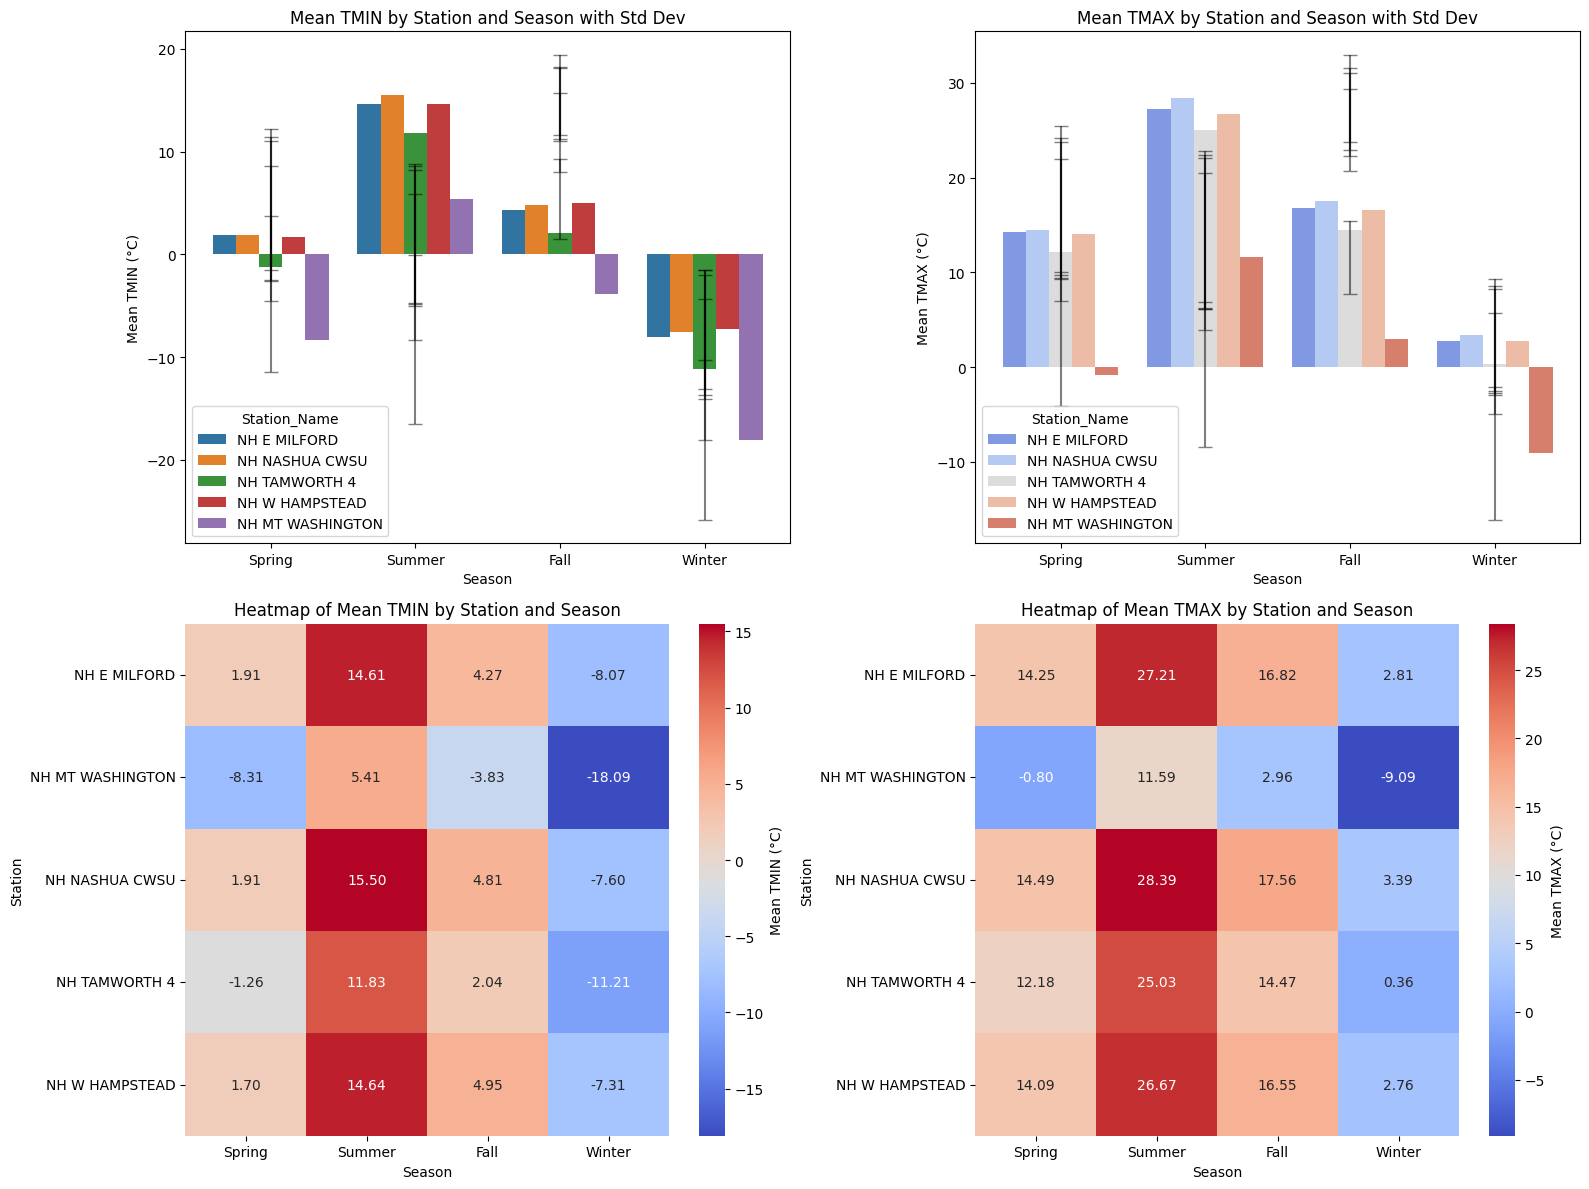

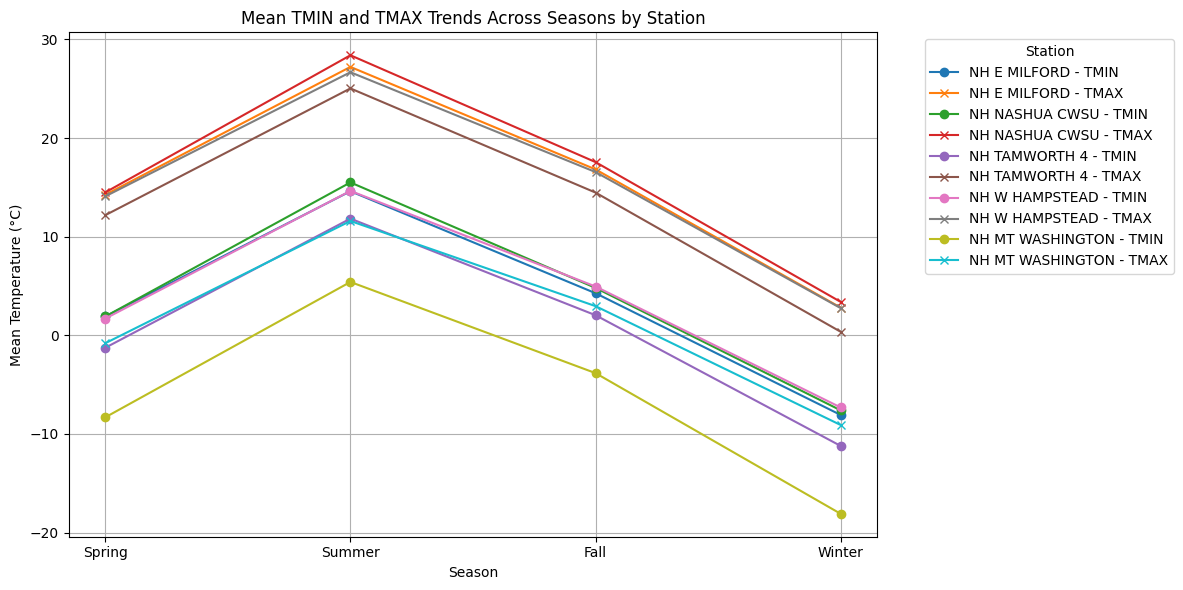

In [4]:
# Compute Station-wise TMIN and TMAX Statistics
stats_list = []
for station_id in df['ID'].unique():
    station_data = df[df['ID'] == station_id]
    station_name = station_data['NAME'].iloc[0]
    
    # Compute statistics for TMIN and TMAX
    stats = station_data.groupby('Season')[['TMIN', 'TMAX']].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
    stats = stats.reset_index()
    
    # Flatten multi-level column headers
    stats.columns = ['Season', 'TMIN_mean', 'TMIN_median', 'TMIN_std', 'TMIN_min', 'TMIN_max', 
                     'TMAX_mean', 'TMAX_median', 'TMAX_std', 'TMAX_min', 'TMAX_max']
    
    stats['Station_ID'] = station_id
    stats['Station_Name'] = station_name
    stats_list.append(stats)

# Combine all statistics into a single DataFrame
tmin_tmax_stats = pd.concat(stats_list, ignore_index=True)

# Correct season order: Spring, Summer, Fall, Winter
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

# Explicitly convert 'Season' column to a categorical type with the correct order
tmin_tmax_stats['Season'] = pd.Categorical(tmin_tmax_stats['Season'], categories=season_order, ordered=True)

# Create subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar Plot: Mean TMIN with Error Bars for Standard Deviation
sns.barplot(data=tmin_tmax_stats, x='Season', y='TMIN_mean', hue='Station_Name', ax=axes[0, 0], errorbar=None)
for station in tmin_tmax_stats['Station_Name'].unique():
    station_data = tmin_tmax_stats[tmin_tmax_stats['Station_Name'] == station]
    axes[0, 0].errorbar(x=range(len(station_data)), 
                        y=station_data['TMIN_mean'], 
                        yerr=station_data['TMIN_std'], 
                        fmt='none', 
                        capsize=5, 
                        color='black', 
                        alpha=0.5)
axes[0, 0].set_title('Mean TMIN by Station and Season with Std Dev')
axes[0, 0].set_xlabel('Season')
axes[0, 0].set_ylabel('Mean TMIN (°C)')

# 2. Bar Plot: Mean TMAX with Error Bars for Standard Deviation
sns.barplot(data=tmin_tmax_stats, x='Season', y='TMAX_mean', hue='Station_Name', ax=axes[0, 1], errorbar=None, palette='coolwarm')
for station in tmin_tmax_stats['Station_Name'].unique():
    station_data = tmin_tmax_stats[tmin_tmax_stats['Station_Name'] == station]
    axes[0, 1].errorbar(x=range(len(station_data)), 
                        y=station_data['TMAX_mean'], 
                        yerr=station_data['TMAX_std'], 
                        fmt='none', 
                        capsize=5, 
                        color='black', 
                        alpha=0.5)
axes[0, 1].set_title('Mean TMAX by Station and Season with Std Dev')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Mean TMAX (°C)')

# 3. Heatmap: Mean TMIN Across Stations and Seasons
pivot_table_tmin = tmin_tmax_stats.pivot(index='Station_Name', columns='Season', values='TMIN_mean')
sns.heatmap(pivot_table_tmin, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Mean TMIN (°C)'}, ax=axes[1, 0])
axes[1, 0].set_title('Heatmap of Mean TMIN by Station and Season')
axes[1, 0].set_xlabel('Season')
axes[1, 0].set_ylabel('Station')

# 4. Heatmap: Mean TMAX Across Stations and Seasons
pivot_table_tmax = tmin_tmax_stats.pivot(index='Station_Name', columns='Season', values='TMAX_mean')
sns.heatmap(pivot_table_tmax, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Mean TMAX (°C)'}, ax=axes[1, 1])
axes[1, 1].set_title('Heatmap of Mean TMAX by Station and Season')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Station')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Line Plot for TMIN and TMAX Trends Across Seasons for Each Station
fig, ax = plt.subplots(figsize=(12, 6))

# Set the season order explicitly
tmin_tmax_stats['Season'] = pd.Categorical(tmin_tmax_stats['Season'], categories=season_order, ordered=True)

# Plot TMIN and TMAX trends for each station
for station in tmin_tmax_stats['Station_Name'].unique():
    station_data = tmin_tmax_stats[tmin_tmax_stats['Station_Name'] == station].sort_values('Season')
    ax.plot(station_data['Season'], station_data['TMIN_mean'], marker='o', label=f'{station} - TMIN')
    ax.plot(station_data['Season'], station_data['TMAX_mean'], marker='x', label=f'{station} - TMAX')

ax.set_title('Mean TMIN and TMAX Trends Across Seasons by Station')
ax.set_xlabel('Season')
ax.set_ylabel('Mean Temperature (°C)')
ax.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)

plt.tight_layout()
plt.show()


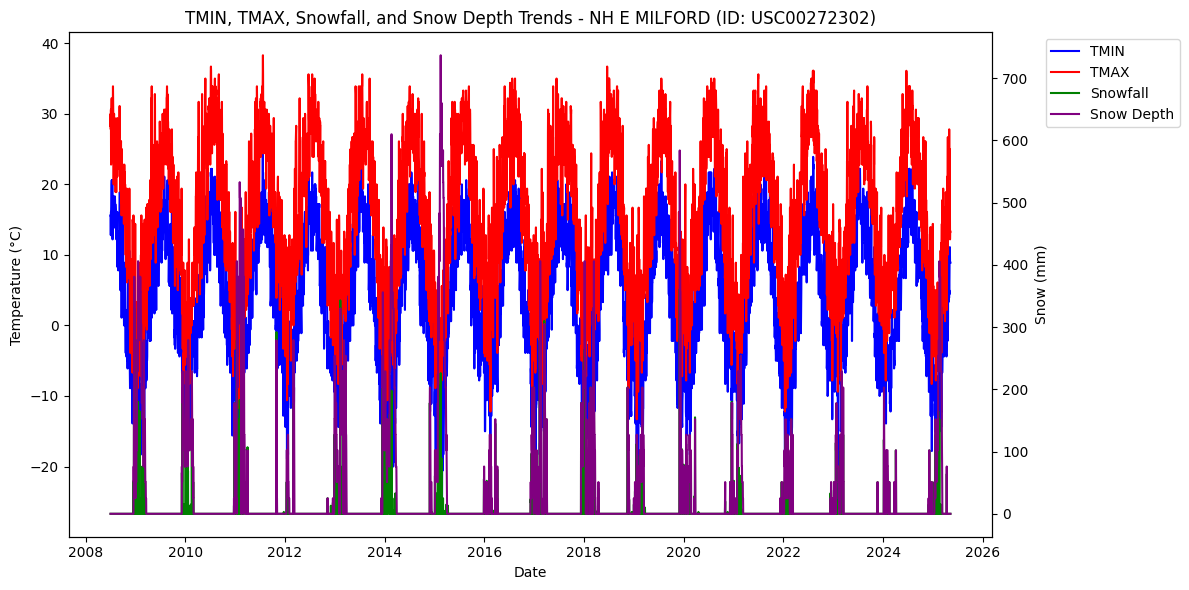

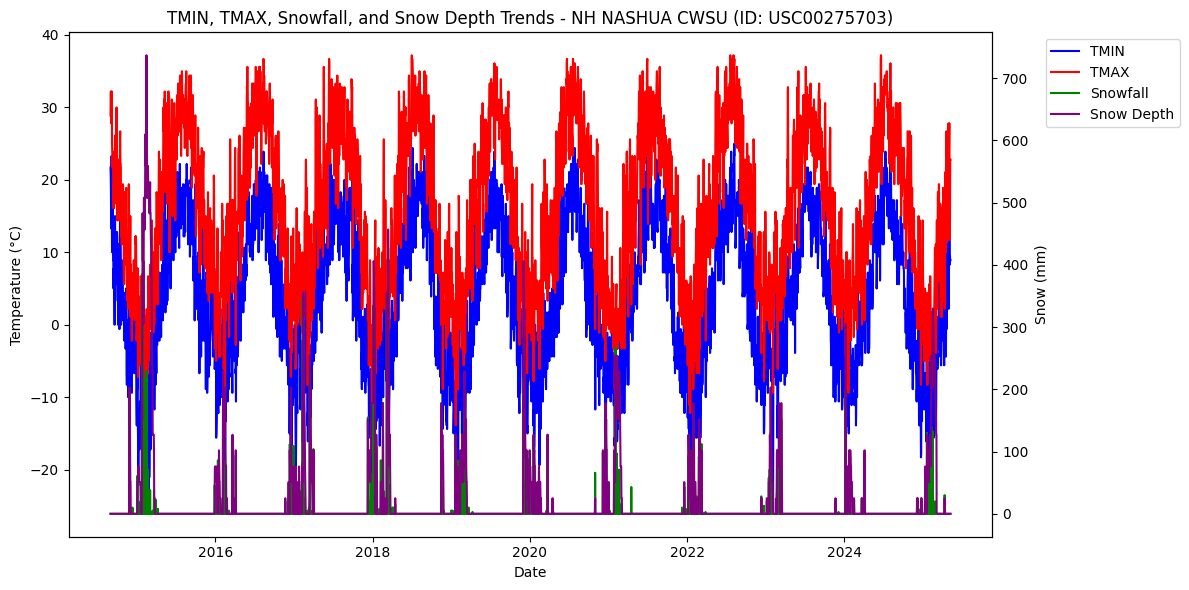

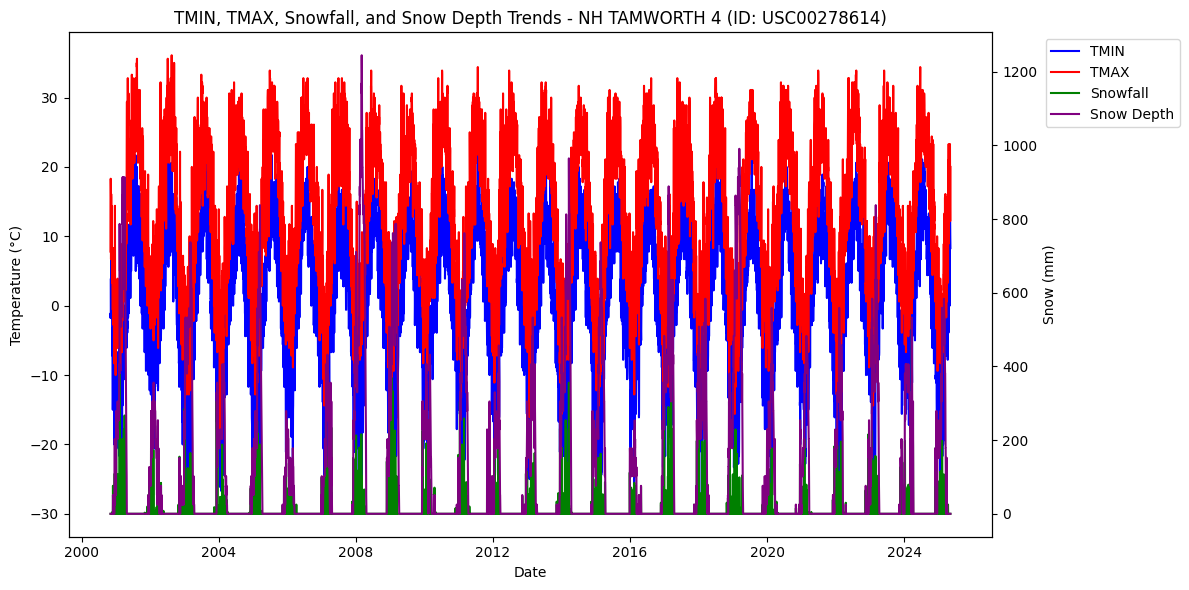

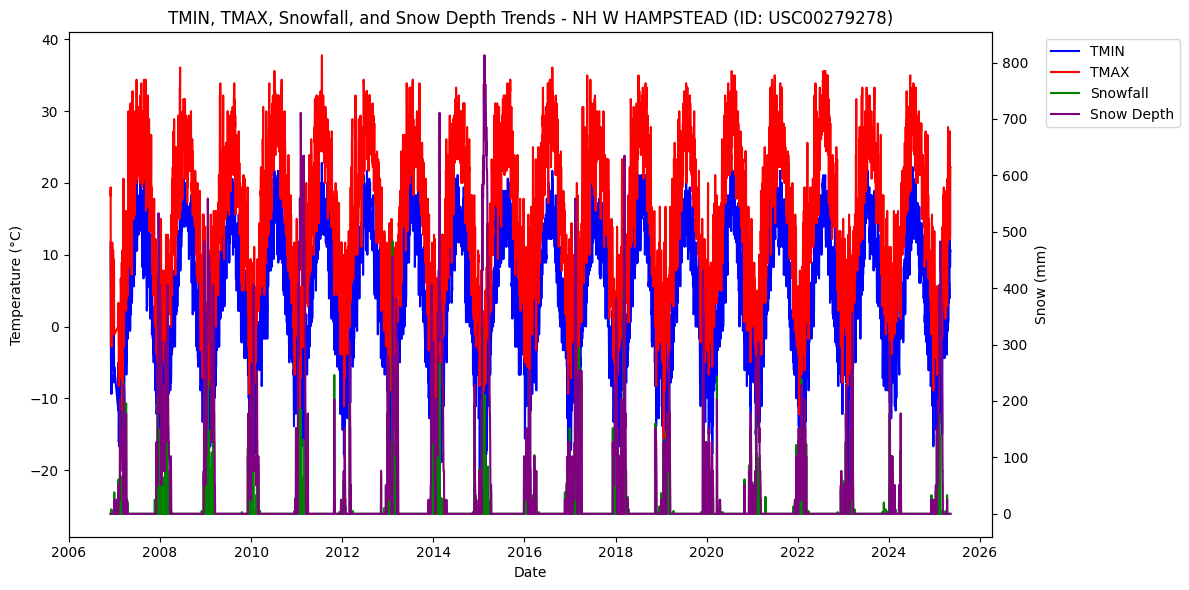

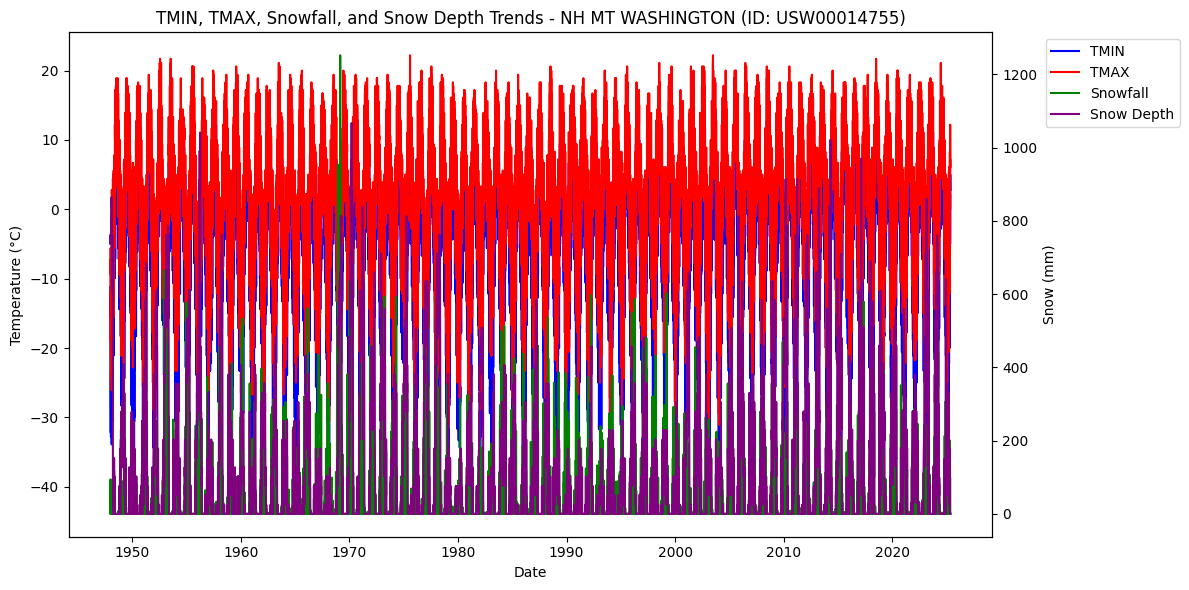

In [5]:
for station_id in df['ID'].unique():
    station_data = df[df['ID'] == station_id]
    plt.figure(figsize=(12, 6))
    
    # Create primary axis for temperature
    ax1 = plt.gca()
    ax1.plot(station_data['DATE'], station_data['TMIN'], label='TMIN', color='blue')
    ax1.plot(station_data['DATE'], station_data['TMAX'], label='TMAX', color='red')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Temperature (°C)', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    
    # Create secondary axis for snow measurements
    ax2 = ax1.twinx()
    ax2.plot(station_data['DATE'], station_data['SNOW'], label='Snowfall', color='green')
    ax2.plot(station_data['DATE'], station_data['SNWD'], label='Snow Depth', color='purple')
    ax2.set_ylabel('Snow (mm)', color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    
    # Title
    plt.title(f"TMIN, TMAX, Snowfall, and Snow Depth Trends - {station_data['NAME'].iloc[0]} (ID: {station_id})")
    
    # Combine legends and place outside the plot
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
    plt.tight_layout()
    plt.show()

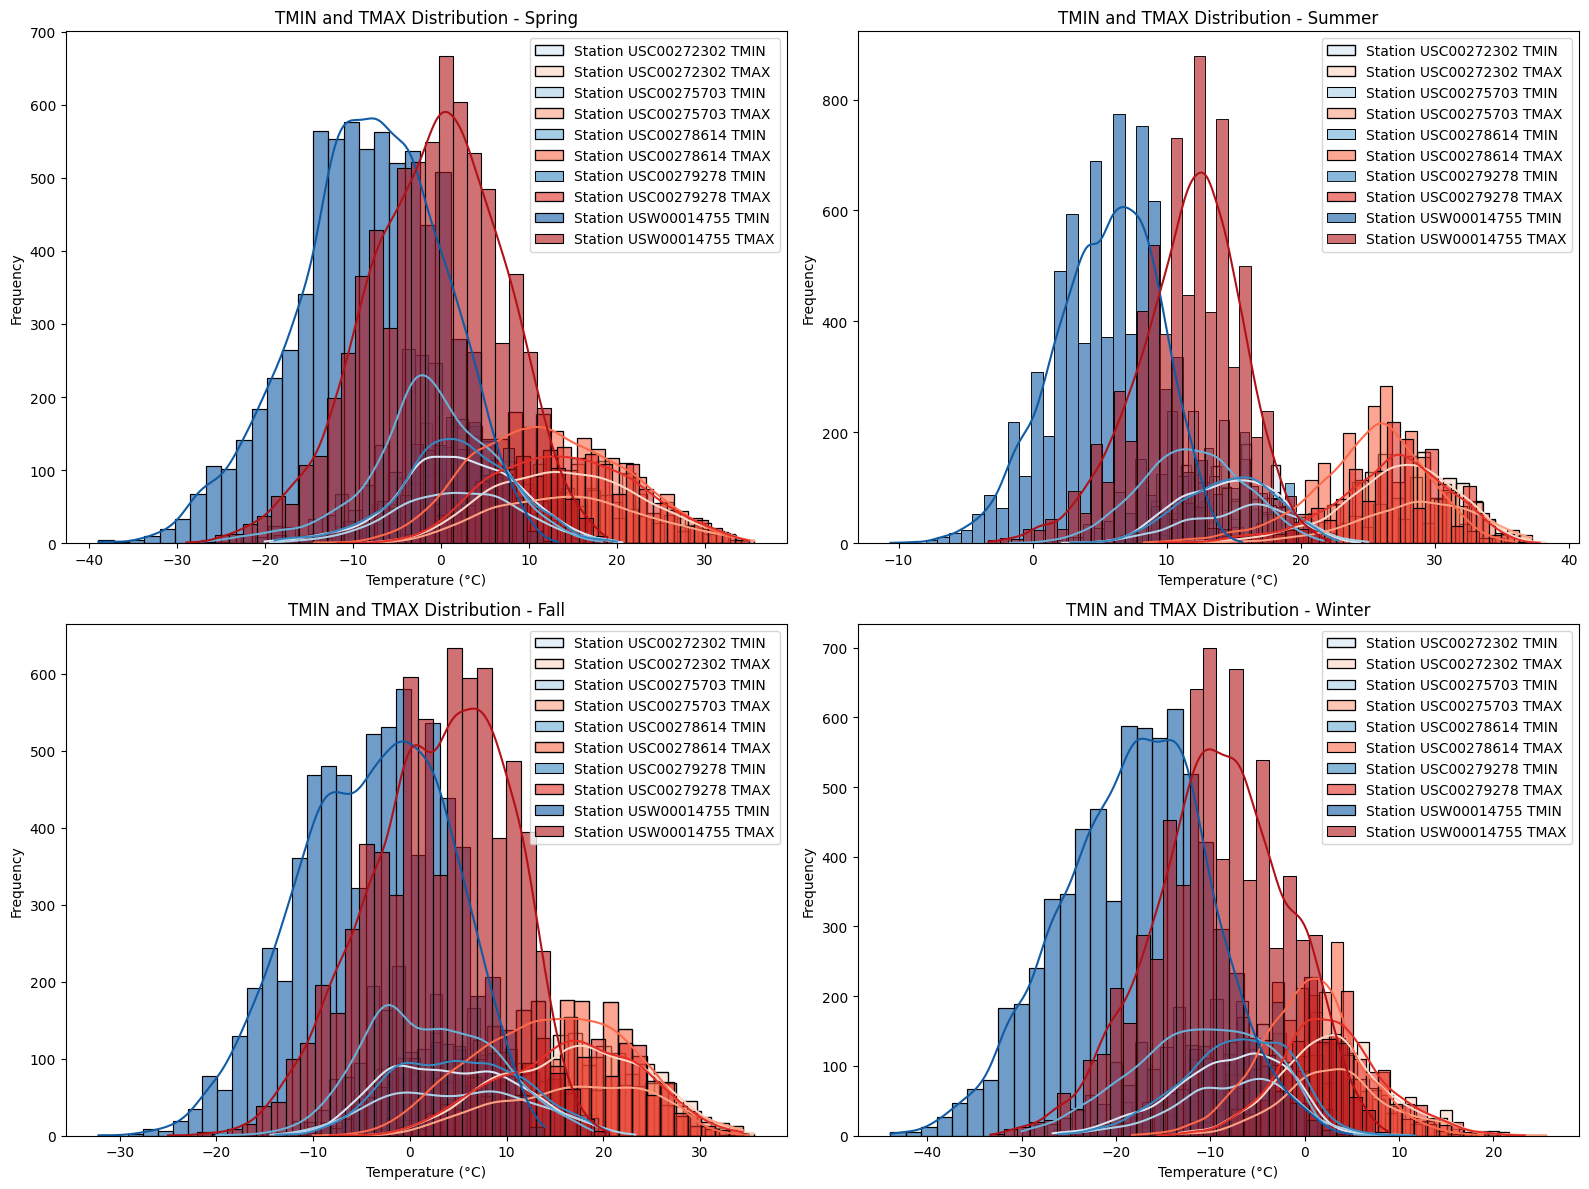

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Correct season order: Spring, Summer, Fall, Winter
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

# Create 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Define a color palette to give unique colors to each station
color_palette_tmin = sns.color_palette("Blues", len(df['ID'].unique()))  # Blue shades for TMIN
color_palette_tmax = sns.color_palette("Reds", len(df['ID'].unique()))   # Red shades for TMAX

# Loop through each season and plot distributions
for i, season in enumerate(season_order):
    ax = axes[i]  # Select the subplot for this season
    
    # Filter the data for the current season
    season_data = df[df['Season'] == season]
    
    # Loop through each station and plot TMIN and TMAX distributions
    for j, station_id in enumerate(season_data['ID'].unique()):
        station_data = season_data[season_data['ID'] == station_id]
        
        # Plot TMIN and TMAX distributions for the current station in the selected subplot
        # Use the j-th color from the TMIN and TMAX palettes
        sns.histplot(station_data['TMIN'], kde=True, bins=30, color=color_palette_tmin[j], alpha=0.6, 
                     label=f'Station {station_id} TMIN', ax=ax)
        sns.histplot(station_data['TMAX'], kde=True, bins=30, color=color_palette_tmax[j], alpha=0.6, 
                     label=f'Station {station_id} TMAX', ax=ax)

    # Customize the subplot
    ax.set_title(f"TMIN and TMAX Distribution - {season}")
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Frequency')
    ax.legend()

# Adjust layout to make sure subplots don't overlap
plt.tight_layout()
plt.show()


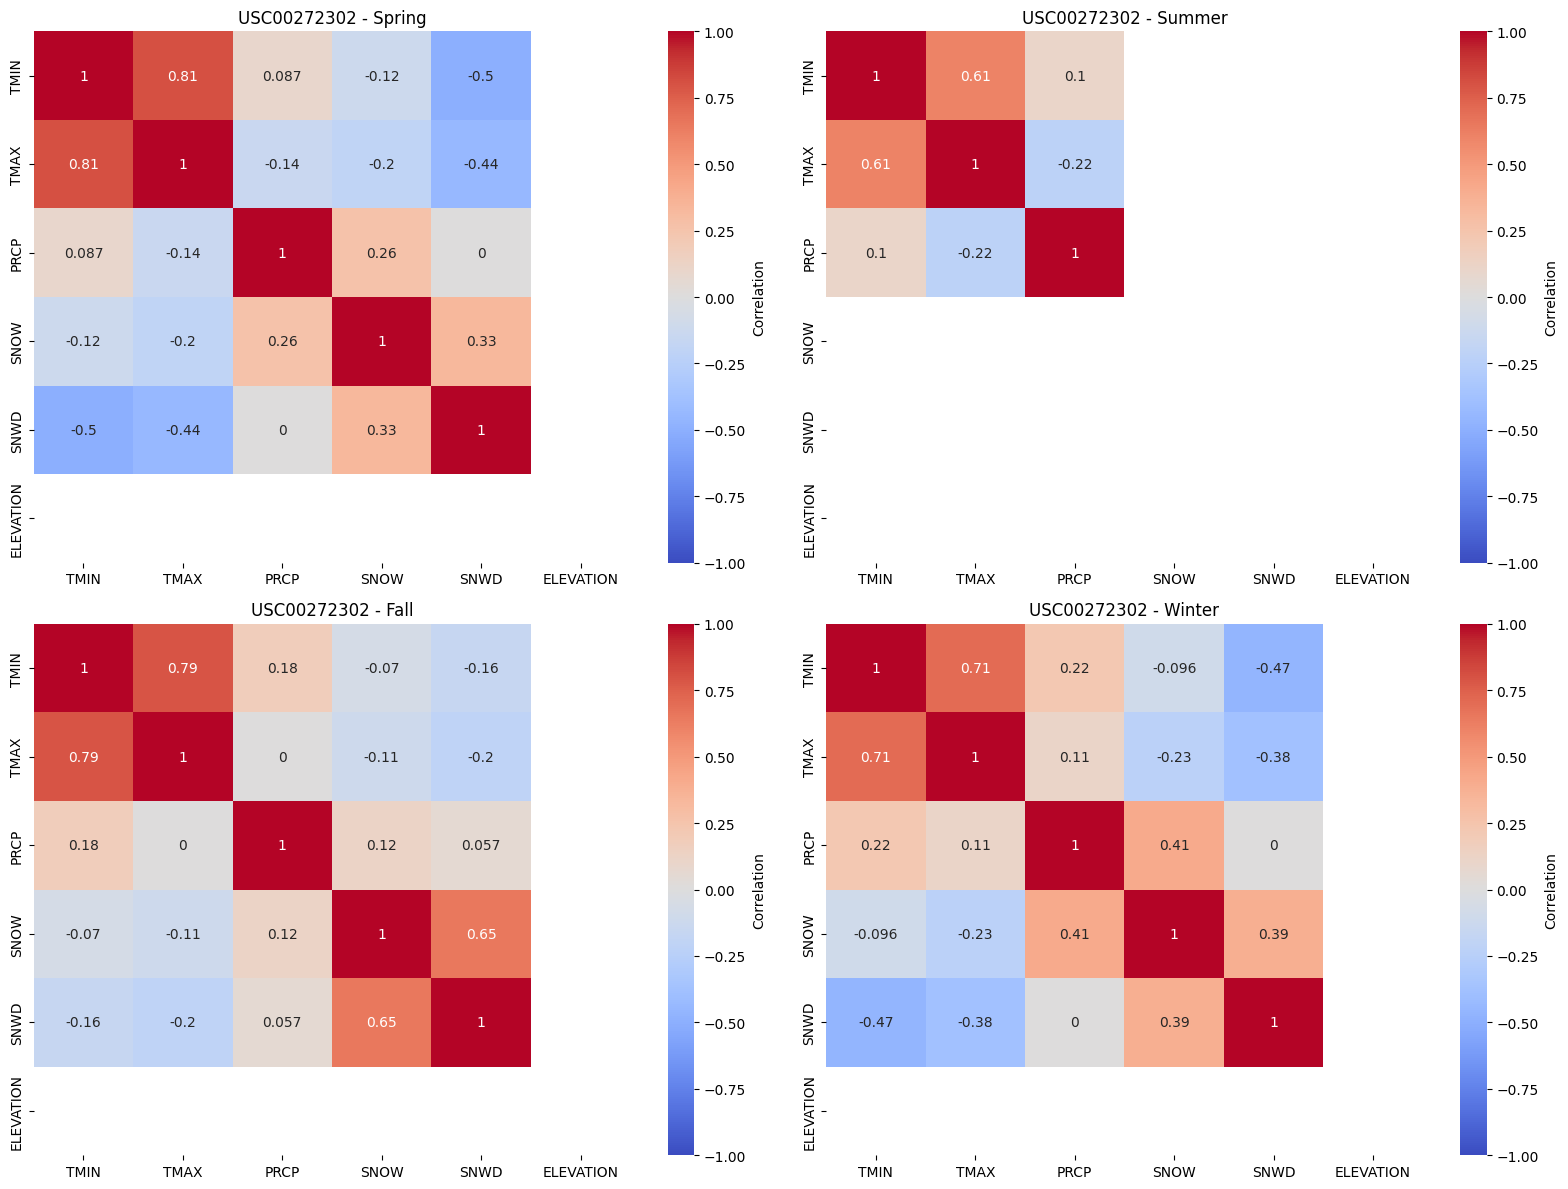

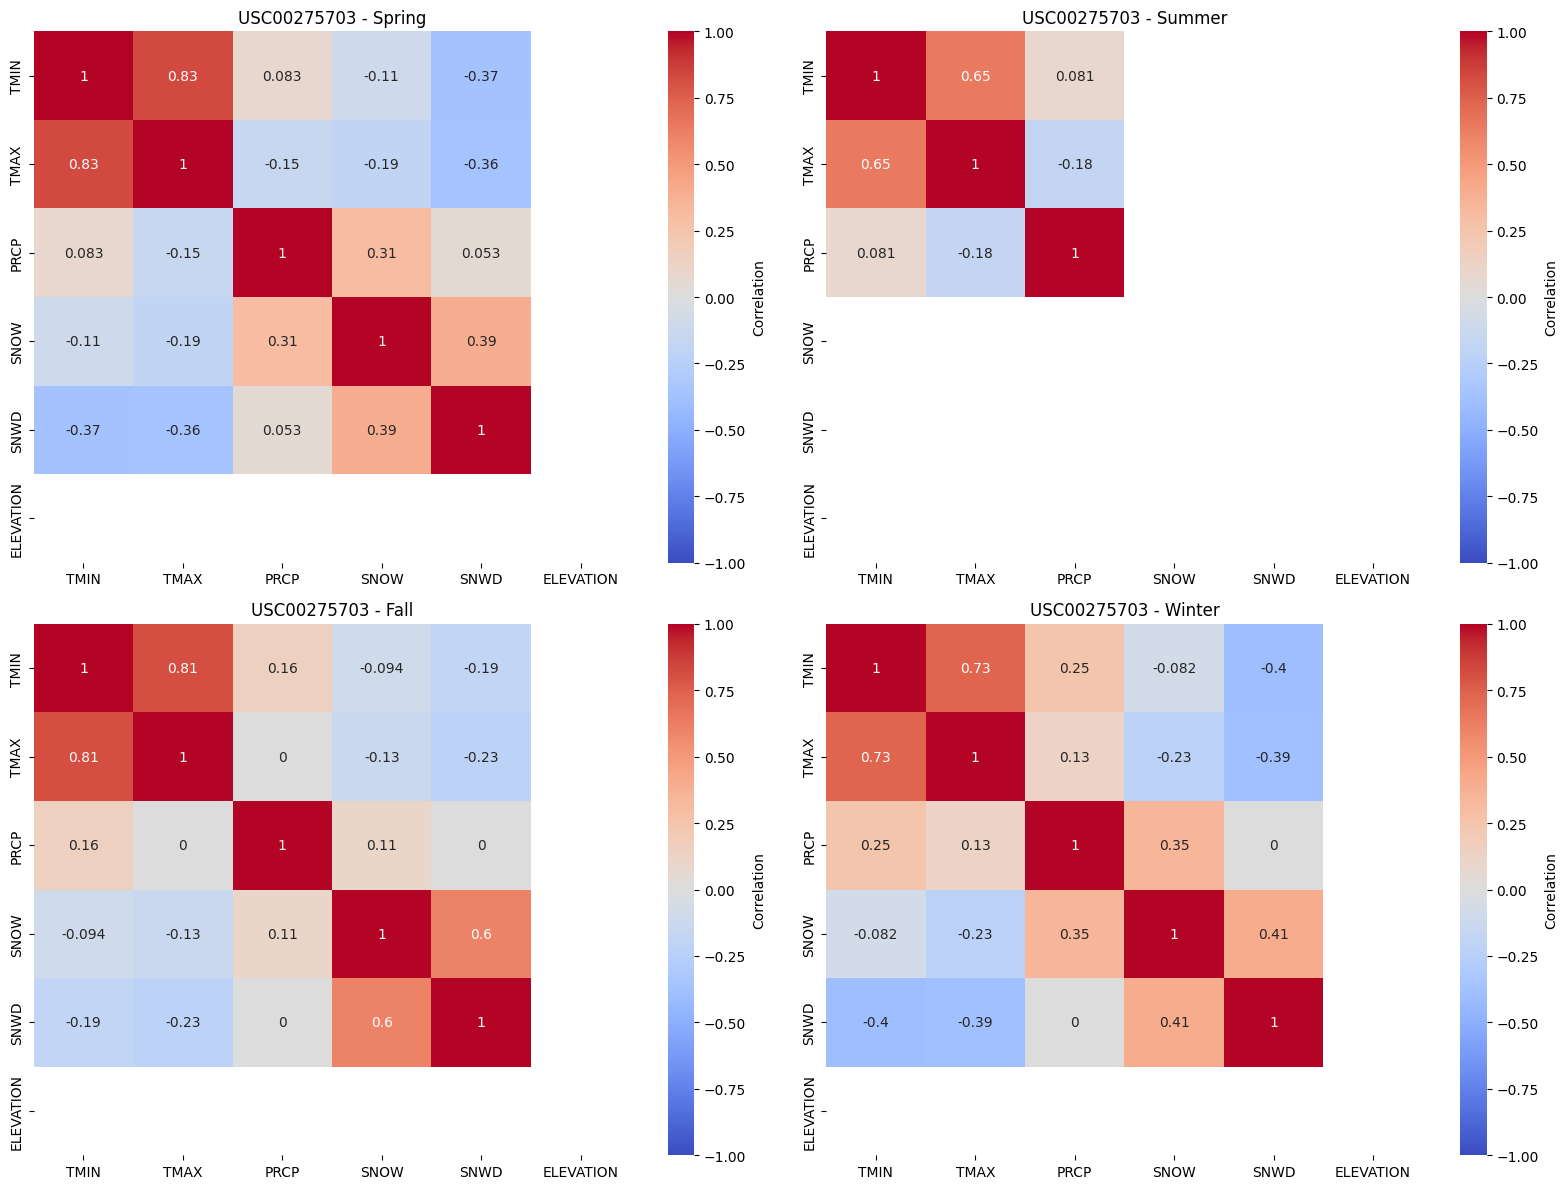

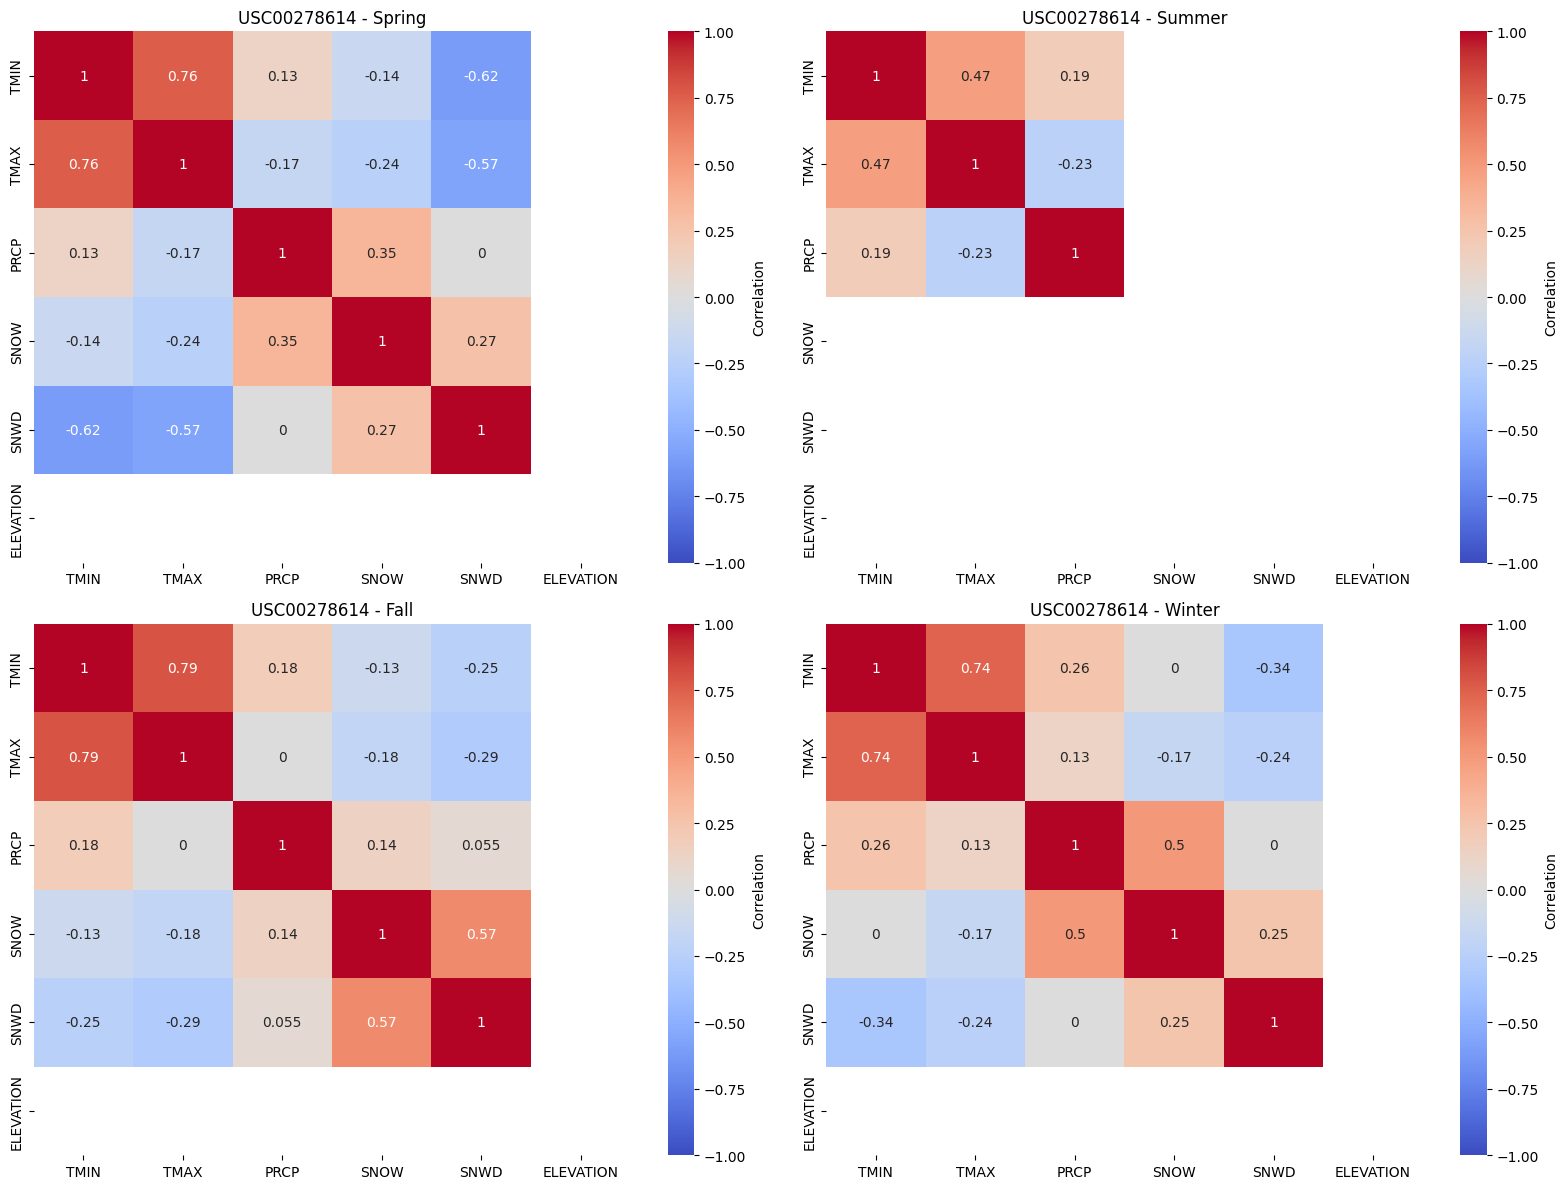

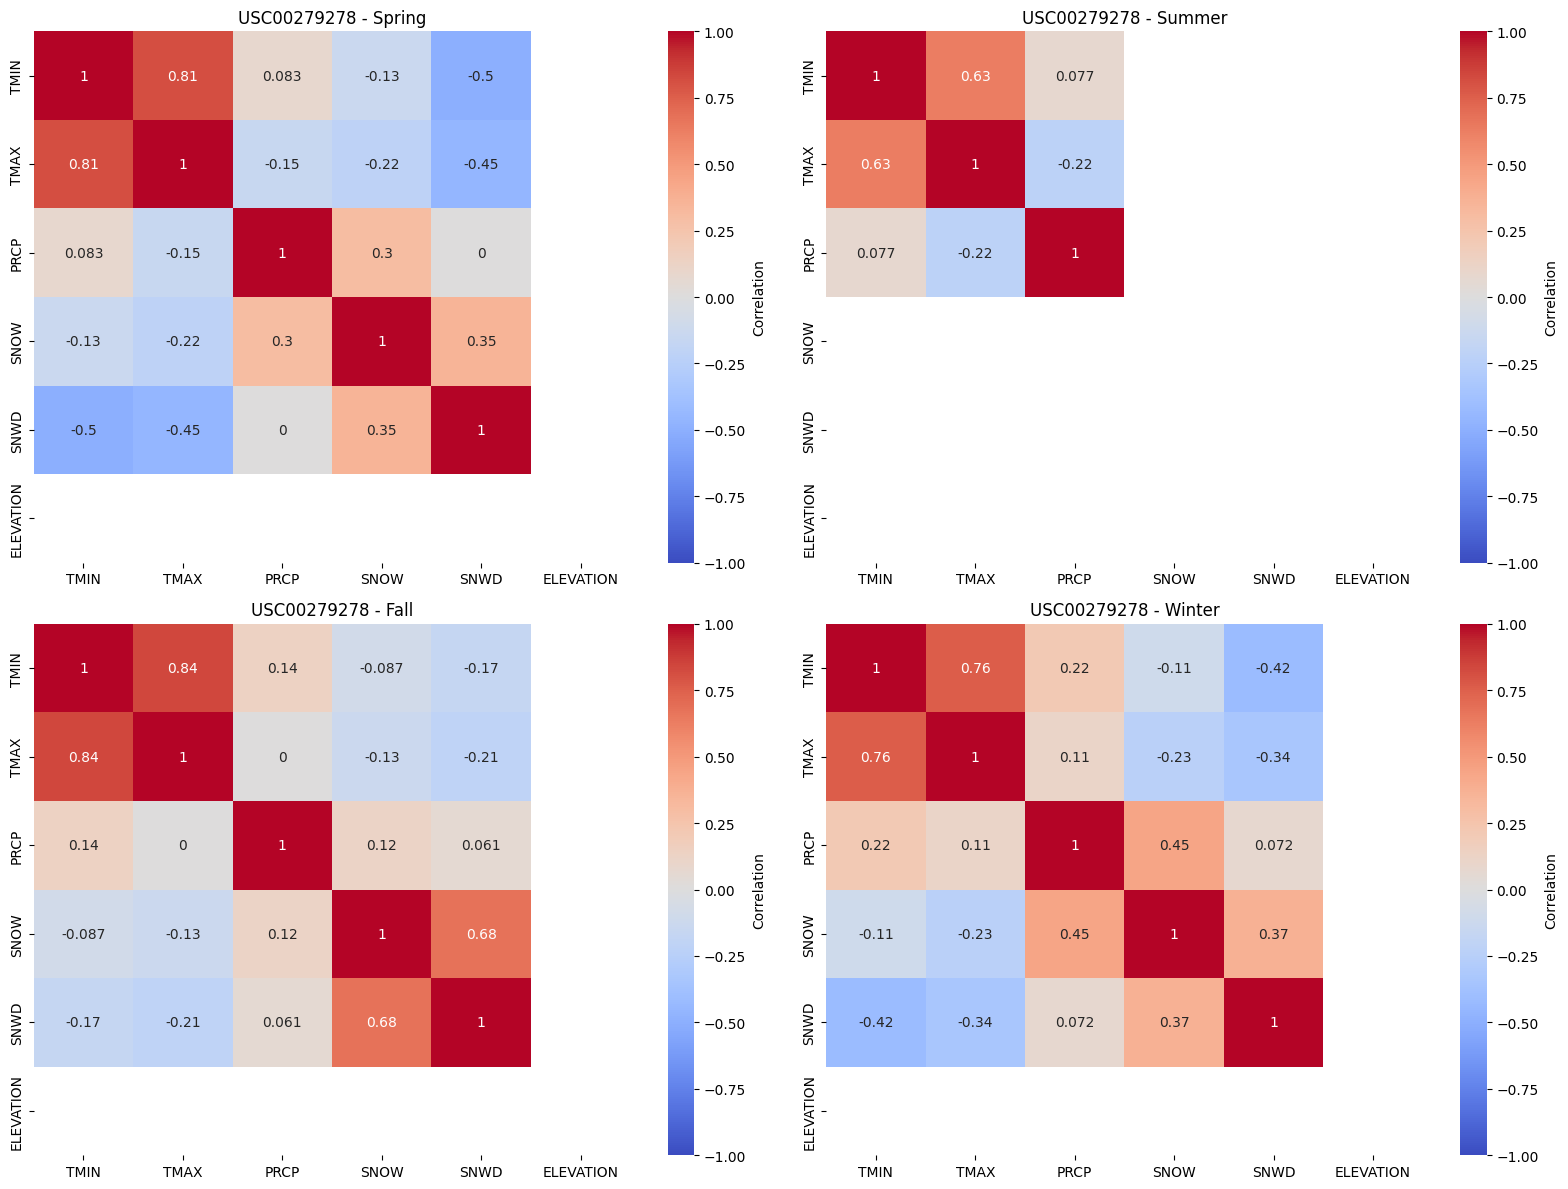

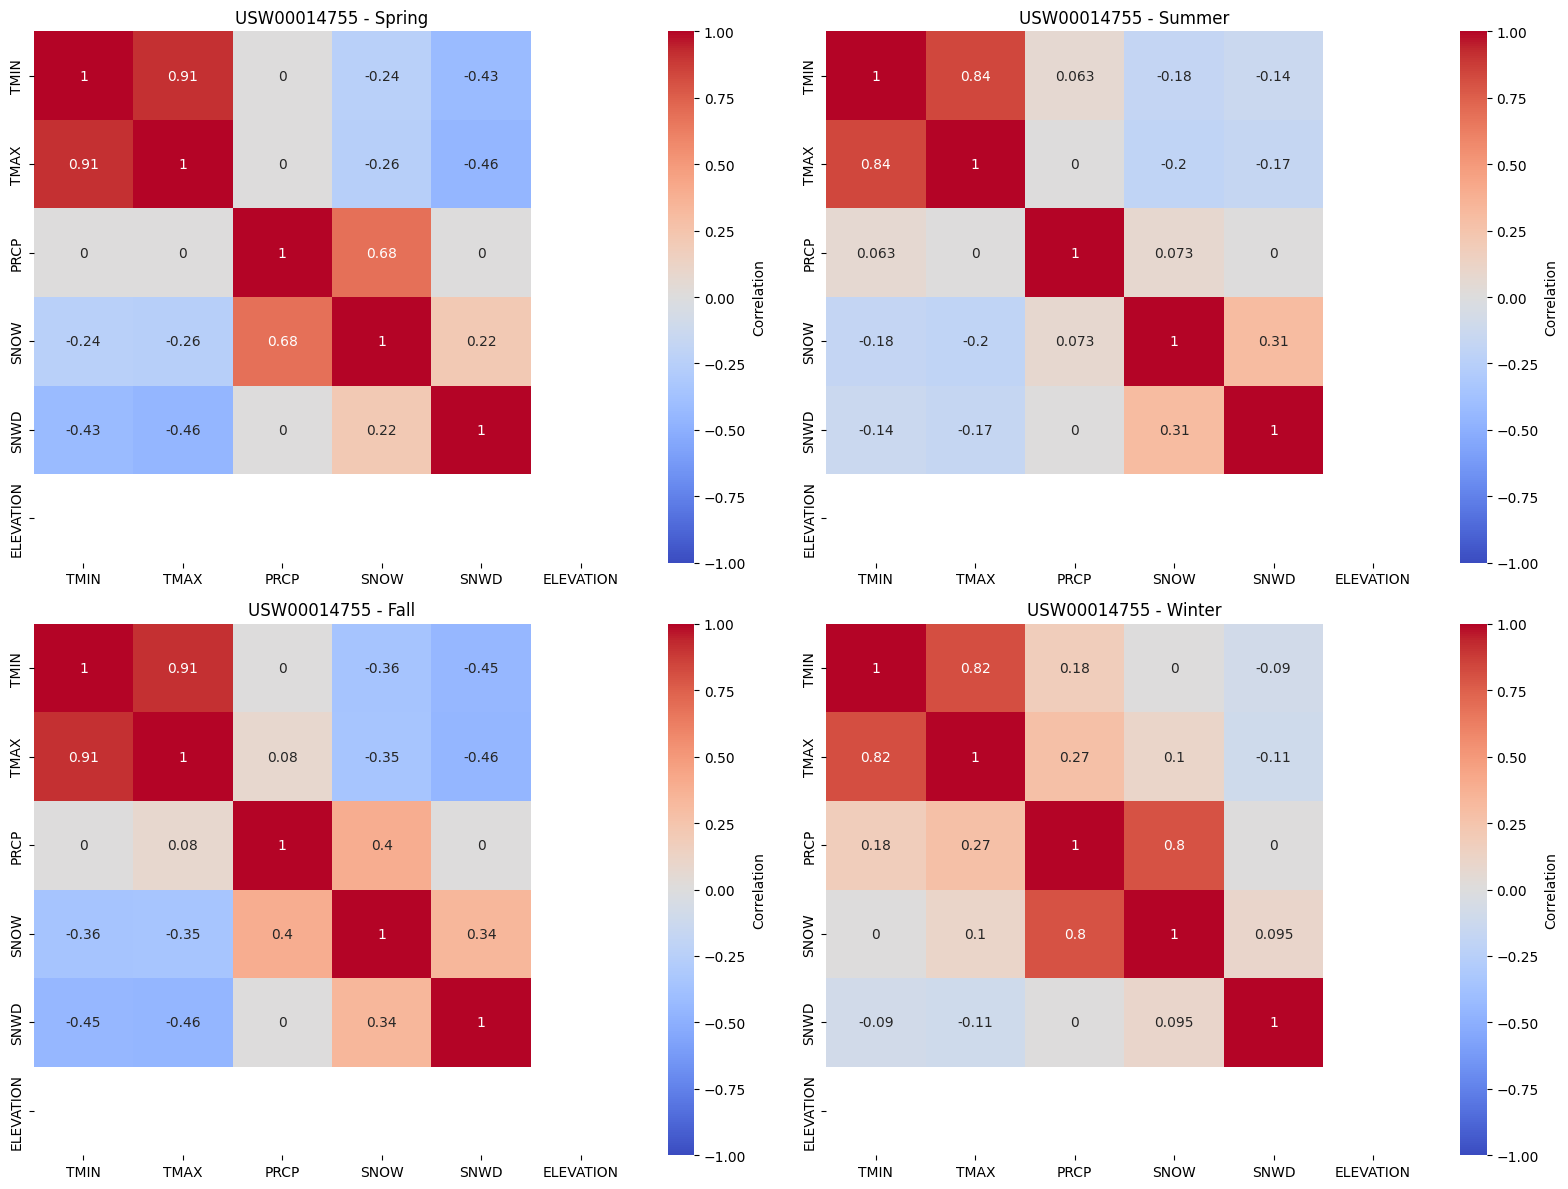

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of numeric columns to consider for correlation
numeric_cols = ['TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD', 'ELEVATION']

# Correct season order: Spring, Summer, Fall, Winter
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

# Get unique station IDs
stations = df['ID'].unique()

# Loop over each station to generate separate figures with 4 subplots (one for each season)
for station_id in stations:
    # Filter the data for the current station
    station_data = df[df['ID'] == station_id]
    
    # Create a figure for the current station with 4 subplots (one for each season)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Loop through each season and generate the correlation matrix for that season
    for i, season in enumerate(season_order):
        ax = axes[i // 2, i % 2]  # Select subplot (2x2 grid)
        
        # Filter data for the current station and season
        station_season_data = station_data[station_data['Season'] == season]
        
        if not station_season_data.empty:
            # Compute the correlation matrix
            correlation_matrix = station_season_data[numeric_cols].corr()
            
            # Mark correlations close to zero as 0 (if very small or no relation)
            correlation_matrix[np.abs(correlation_matrix) < 0.05] = 0
            
            # Plot the heatmap
            sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Correlation'})
            
            # Set the title for the subplot
            ax.set_title(f'{station_id} - {season}')
        else:
            ax.set_visible(False)  # If no data for that station-season combination, hide the subplot
    
    # Adjust layout for better spacing between subplots
    plt.tight_layout()
    
    # Show the figure for the current station
    plt.show()
